In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Resolve paths

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

DATA_PATH  = PROJECT_ROOT / "data" / "processed" / "players_cleaned.csv"

df = pd.read_csv(DATA_PATH)
df.shape

(2029, 18)

In [3]:
df.head()

,player_name,nation,position,squad,compition,age_years,born_year,match_played,starts,min,goal,assist,expected_goal,expected_assisted_goal,non-penalty_expected_goal,progressive_carries,progressive_passes,progressive_passes_receive
0,Brenden Aaronson,USA,"MF,FW",Leeds United,Premier League,22,2000,26,23,1948.0,1.0,2.0,2.9,3.7,2.9,36.00,72.0,120.00
1,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35,1987,28,28,2520.0,1.0,1.0,1.8,0.4,1.8,20.00,147.0,5.00
2,Himad Abdelli,FRA,"MF,FW",Angers,Ligue 1,23,1999,20,14,1261.0,0.9,1.0,34.0,74.0,84.0,0.06,0.2,0.06
3,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,23,2000,26,26,2336.0,1.0,1.0,0.8,1.5,0.8,28.00,140.0,37.00
4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,20,19,1551.0,0.4,1.0,8.0,1.4,1.1,0.02,10.0,0.06


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   player_name                 2029 non-null   object 
 1   nation                      2029 non-null   object 
 2   position                    2029 non-null   object 
 3   squad                       2029 non-null   object 
 4   compition                   2029 non-null   object 
 5   age_years                   2029 non-null   int64  
 6   born_year                   2029 non-null   int64  
 7   match_played                2029 non-null   int64  
 8   starts                      2029 non-null   int64  
 9   min                         2029 non-null   float64
 10  goal                        1994 non-null   float64
 11  assist                      2016 non-null   float64
 12  expected_goal               2002 non-null   float64
 13  expected_assisted_goal      1911 

In [5]:
df.isna().sum().sort_values(ascending=False)

progressive_passes_receive    528
progressive_passes            367
progressive_carries           360
expected_assisted_goal        118
non-penalty_expected_goal      37
goal                           35
expected_goal                  27
assist                         13
nation                          0
player_name                     0
starts                          0
match_played                    0
born_year                       0
age_years                       0
compition                       0
squad                           0
position                        0
min                             0
dtype: int64

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_years,2029.0,26.764416,4.197150,17.0,24.00,26.0,30.000,40.0
born_year,2029.0,1995.551503,4.203869,1982.0,1993.00,1996.0,1999.000,2006.0
match_played,2029.0,18.285855,6.191480,4.0,14.00,19.0,24.000,28.0
starts,2029.0,13.852144,7.259682,1.0,7.00,14.0,20.000,28.0
min,2029.0,1231.033021,607.401143,300.0,682.00,1192.0,1718.000,2520.0
goal,1994.0,2.165446,3.511004,0.0,0.50,1.0,2.375,76.0
assist,2016.0,2.227480,1.823418,0.0,1.00,2.0,3.000,19.0
expected_goal,2002.0,7.227223,10.939804,0.0,1.10,2.9,8.575,137.0
expected_assisted_goal,1911.0,7.866855,16.915693,0.0,1.00,2.0,4.800,195.0
non-penalty_expected_goal,1992.0,7.941034,18.326906,0.0,0.70,1.4,3.800,148.0


In [16]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print("Numerical Columns: ", numeric_cols)
print("Categorical Columns: ", categorical_cols)

Numerical Columns:  ['age_years', 'born_year', 'match_played', 'starts', 'min', 'goal', 'assist', 'expected_goal', 'expected_assisted_goal', 'non-penalty_expected_goal', 'progressive_carries', 'progressive_passes', 'progressive_passes_receive']
Categorical Columns:  ['player_name', 'nation', 'position', 'squad', 'compition']


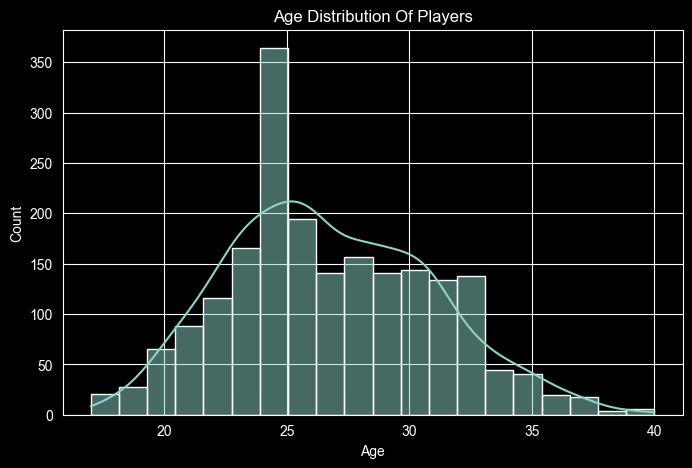

In [6]:
#Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['age_years'], bins=20, kde=True)
plt.title("Age Distribution Of Players")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

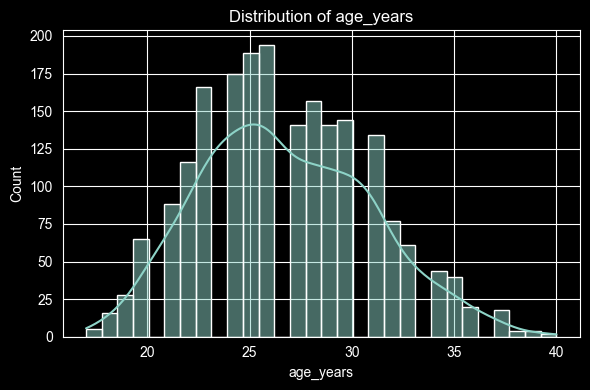

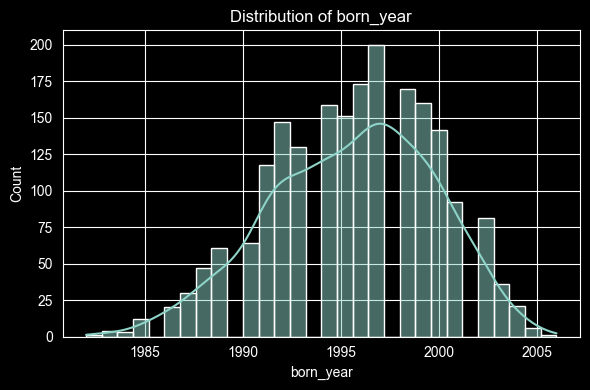

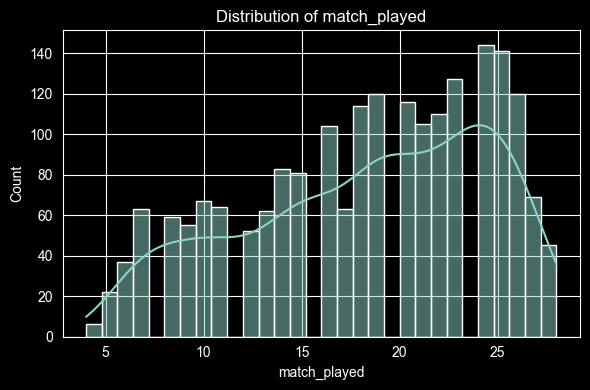

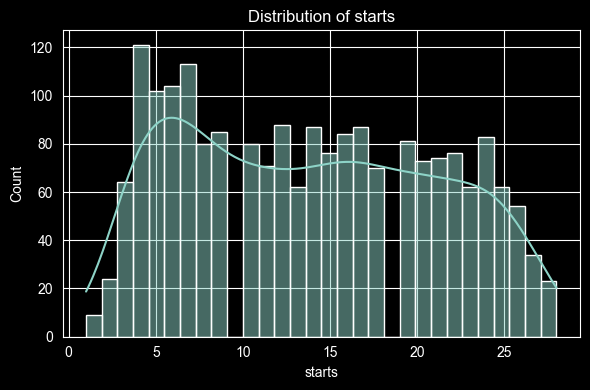

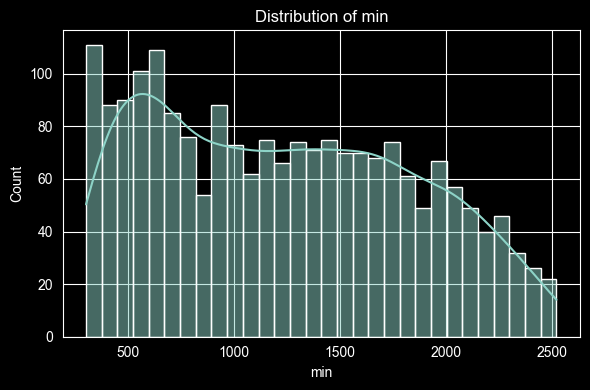

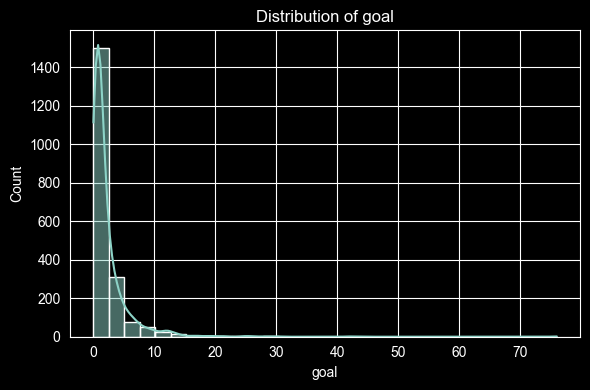

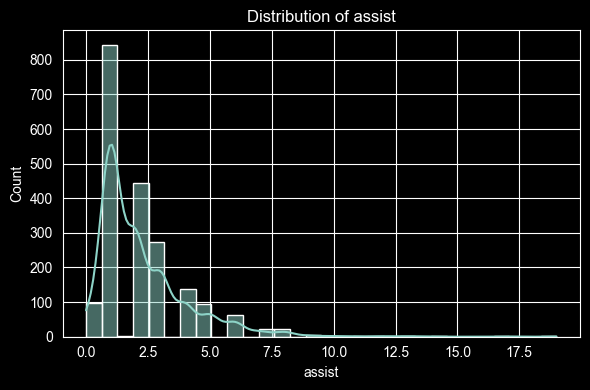

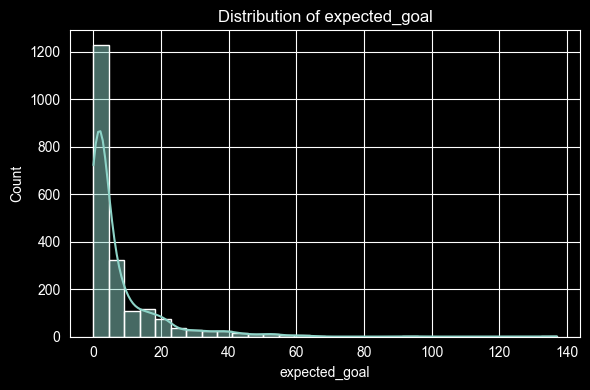

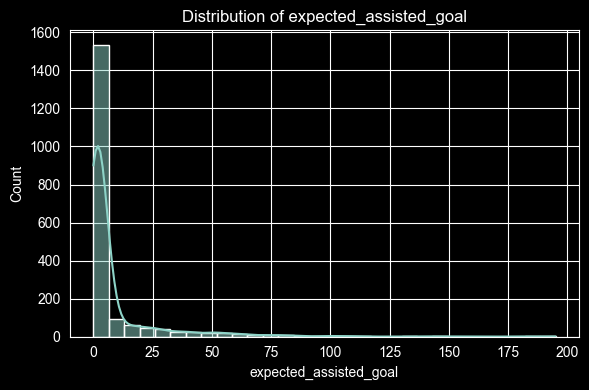

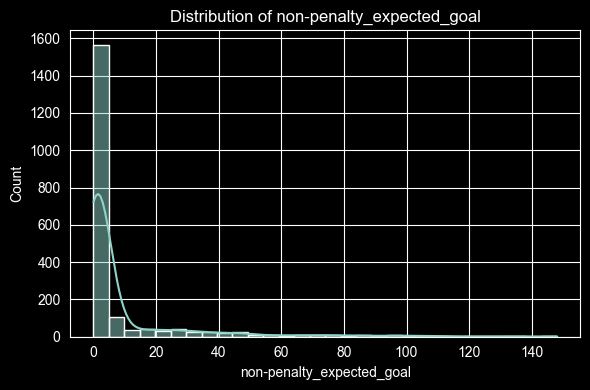

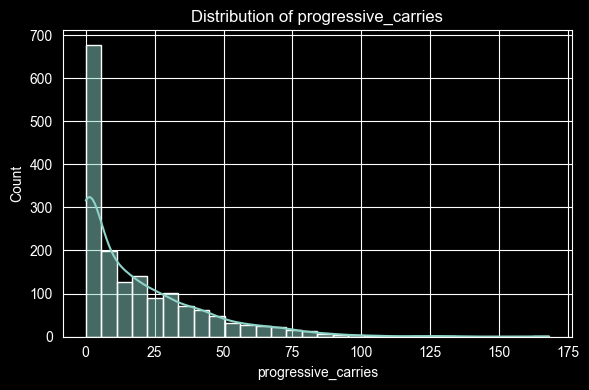

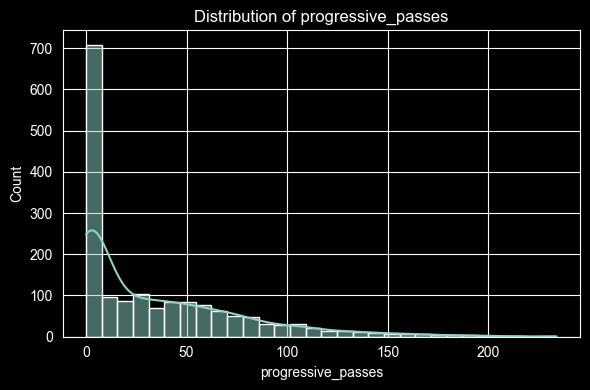

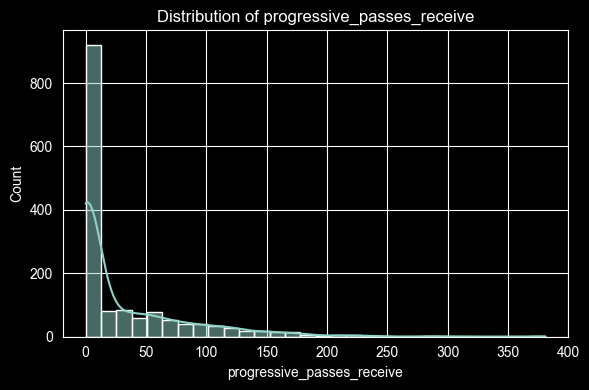

In [17]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],bins=30,kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

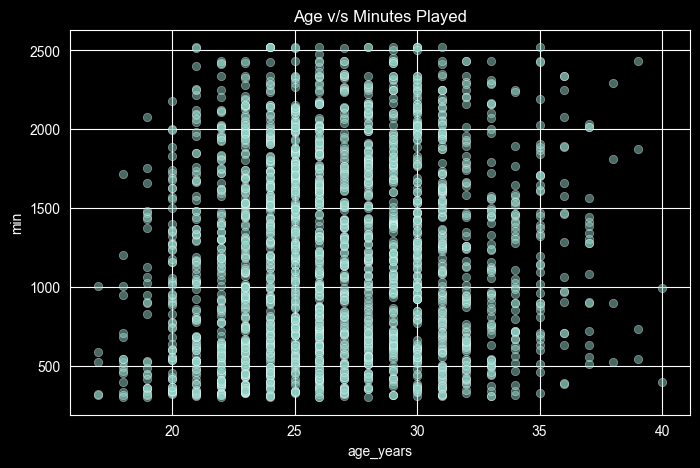

In [9]:
#Scatter Plot between age and minutes played
plt.figure(figsize=(8,5))
sns.scatterplot(x="age_years", y="min", data=df, alpha=0.5)
plt.title("Age v/s Minutes Played")
plt.show()

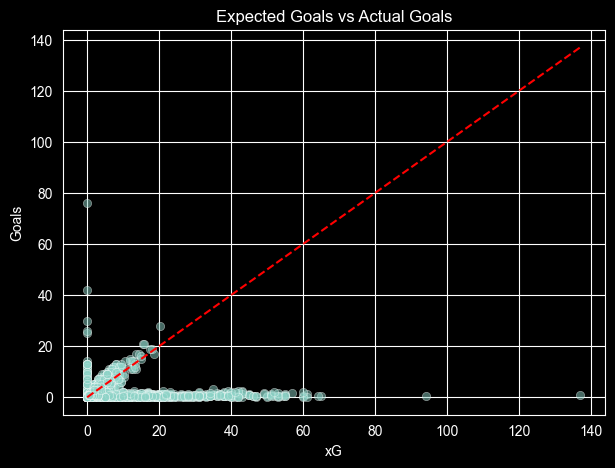

In [11]:
#ScatterPlot between xG and Goals scored
plt.figure(figsize=(7,5))
sns.scatterplot(x="expected_goal",y='goal',data=df, alpha=0.5)
plt.plot([0,df['expected_goal'].max()],
         [0,df['expected_goal'].max()],
         color="red",linestyle="--")
plt.title("Expected Goals vs Actual Goals")
plt.xlabel("xG")
plt.ylabel("Goals")
plt.show()



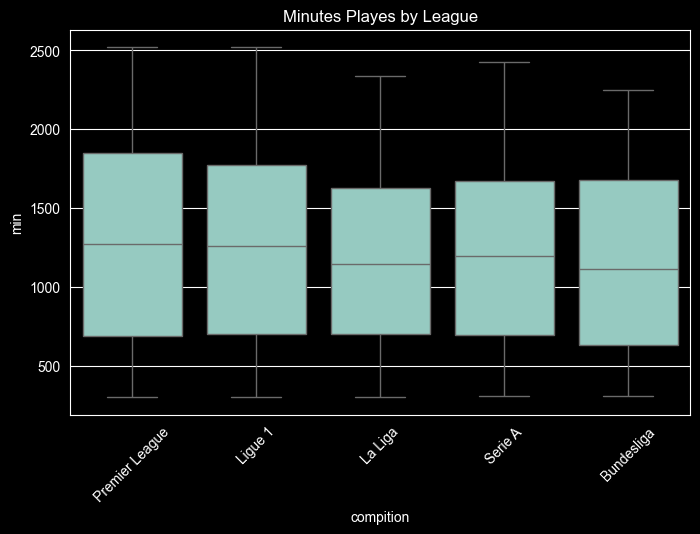

In [12]:
#League wise distribution

plt.figure(figsize=(8,5))
sns.boxplot(x='compition',y='min',data=df)
plt.title("Minutes Playes by League")
plt.xticks(rotation=45)
plt.show()

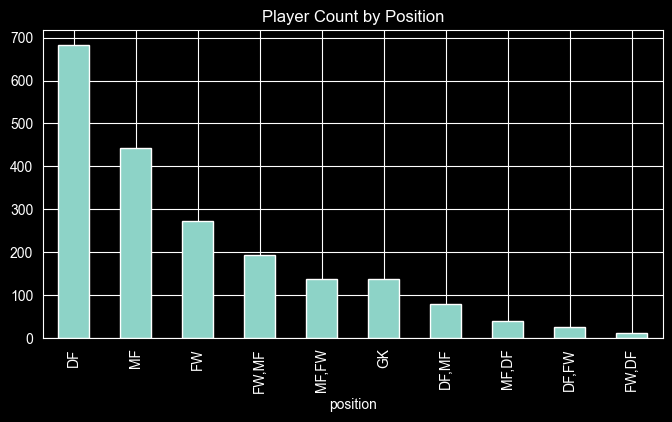

In [13]:
#Position Imbalance

df['position'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title("Player Count by Position")
plt.show()

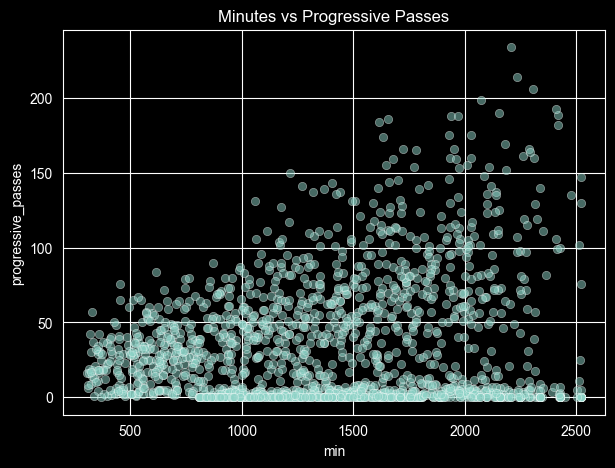

In [14]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='min',y='progressive_passes',data=df,
    alpha=0.5
)
plt.title("Minutes vs Progressive Passes")
plt.show()

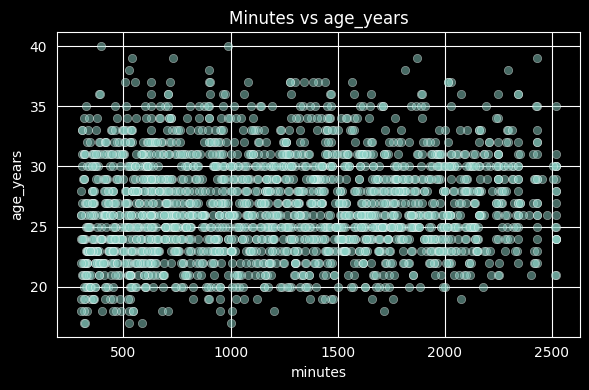

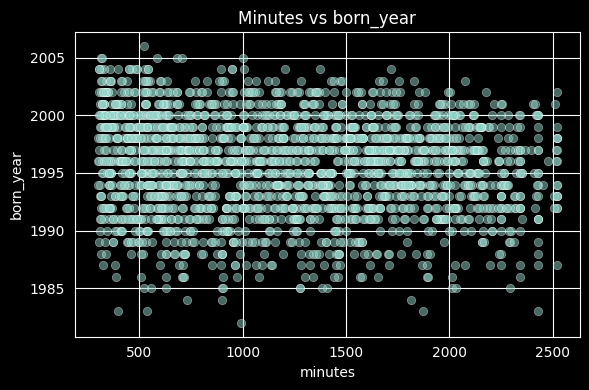

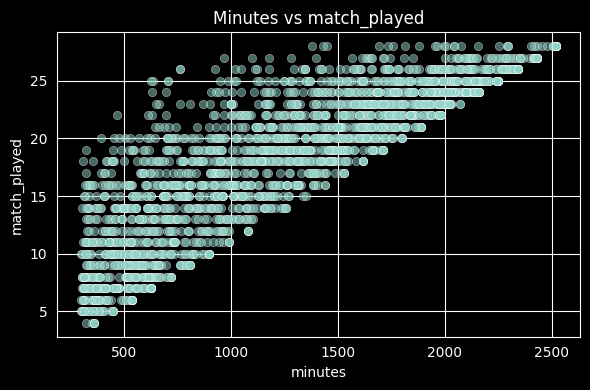

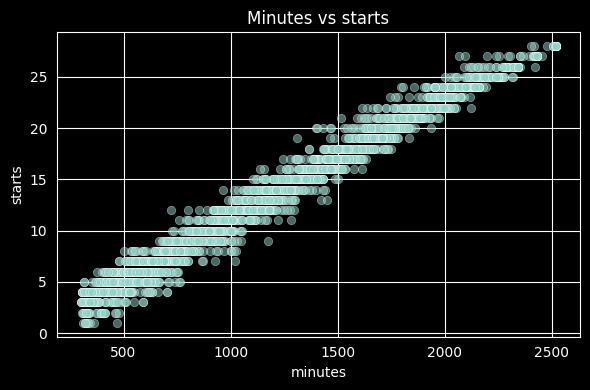

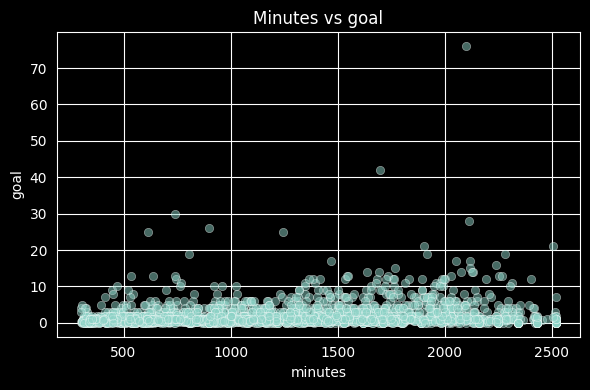

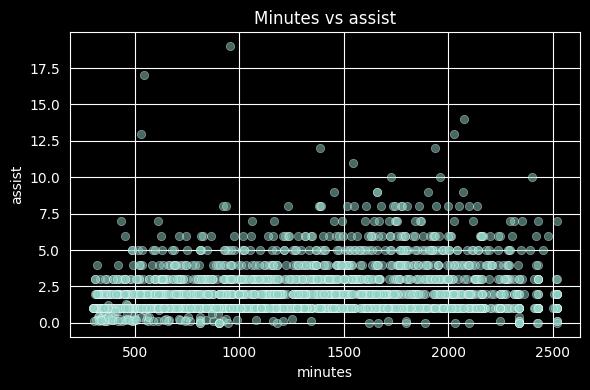

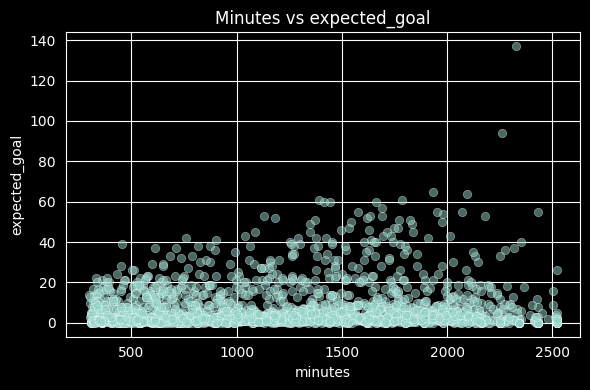

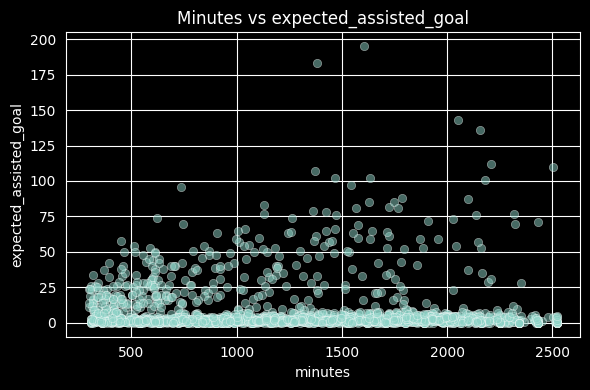

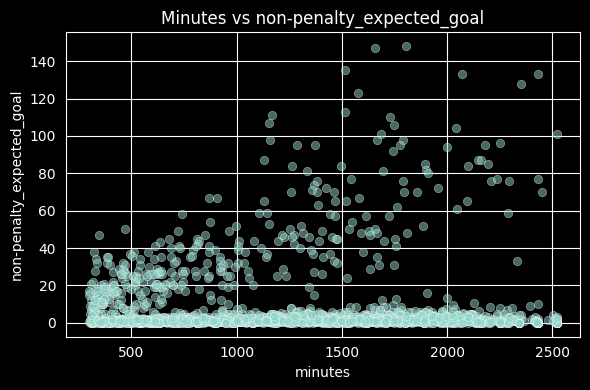

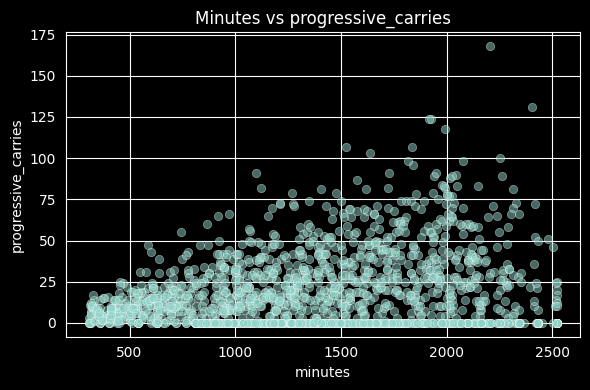

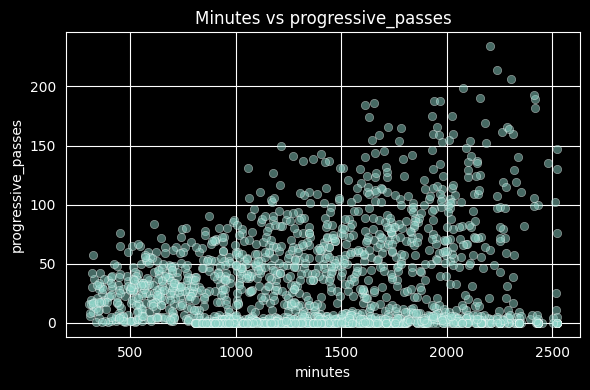

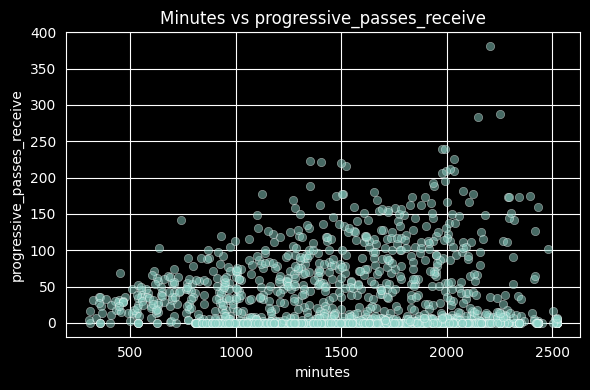

In [20]:
for col in numeric_cols:
    if col!= "min":
        plt.figure(figsize=(6,4))
        sns.scatterplot(x='min',y=col,data=df,alpha=0.5)
        plt.title(f"Minutes vs {col}")
        plt.xlabel("minutes")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

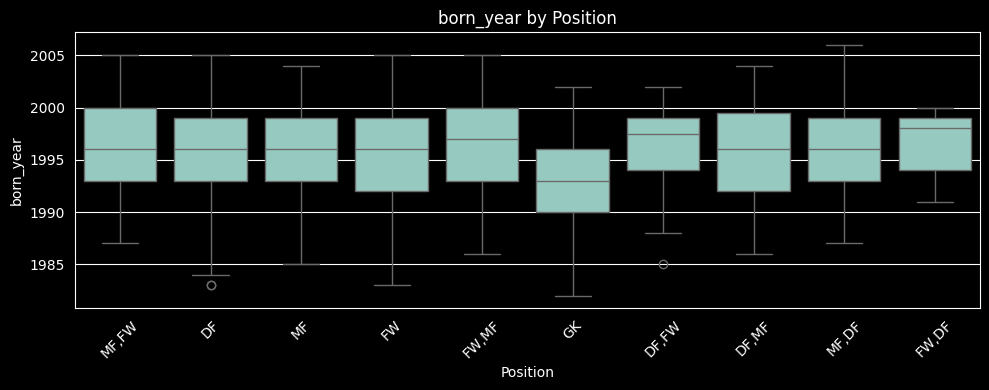

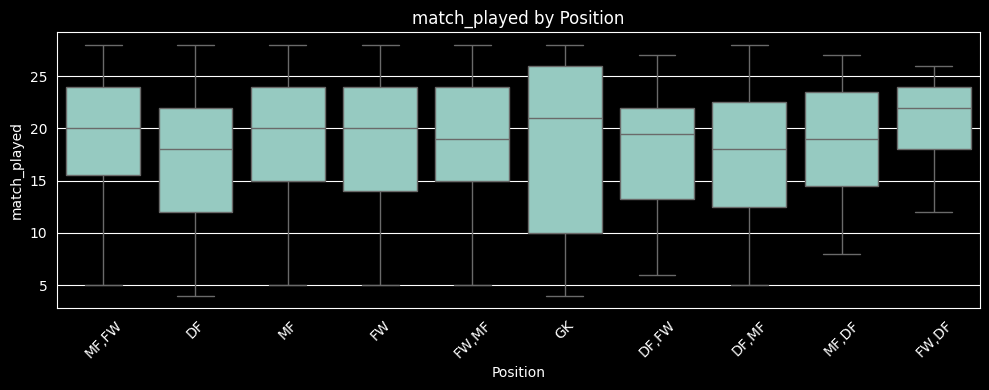

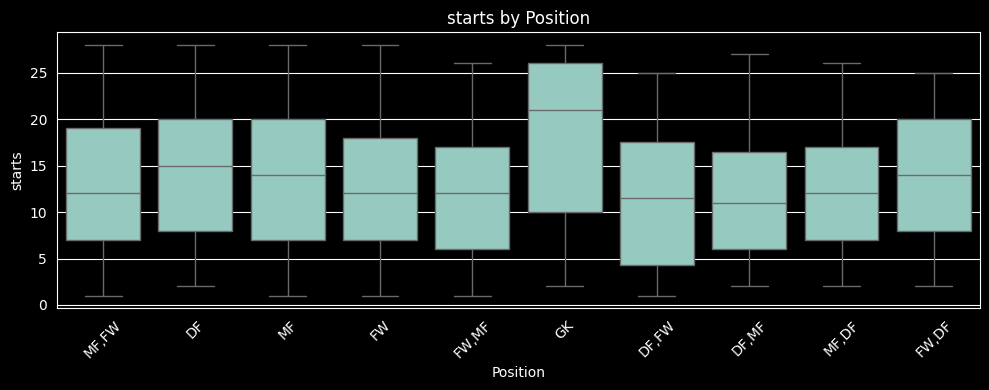

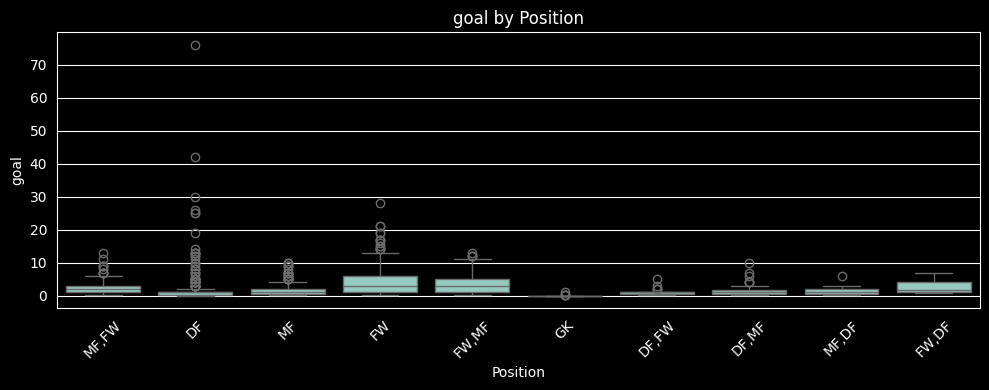

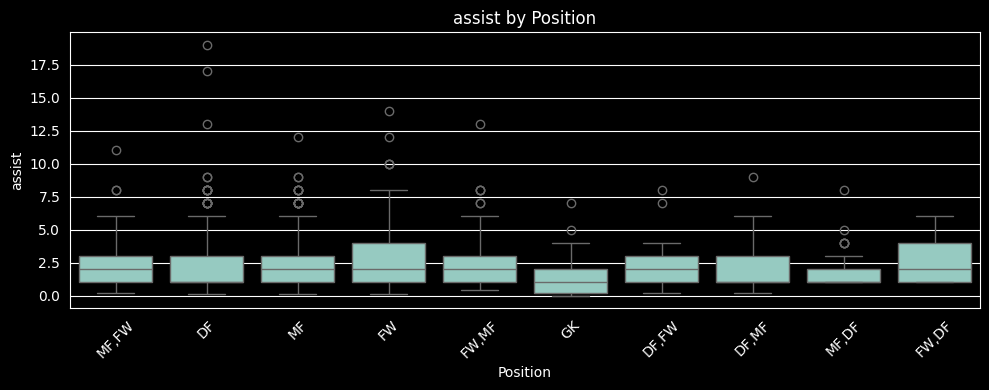

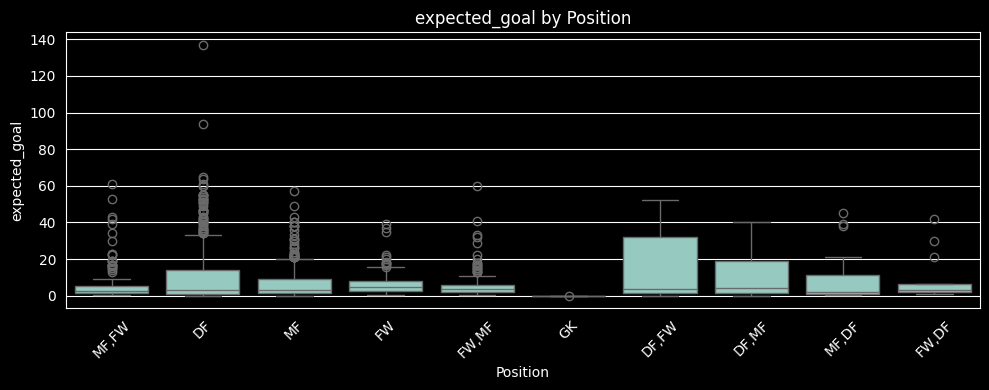

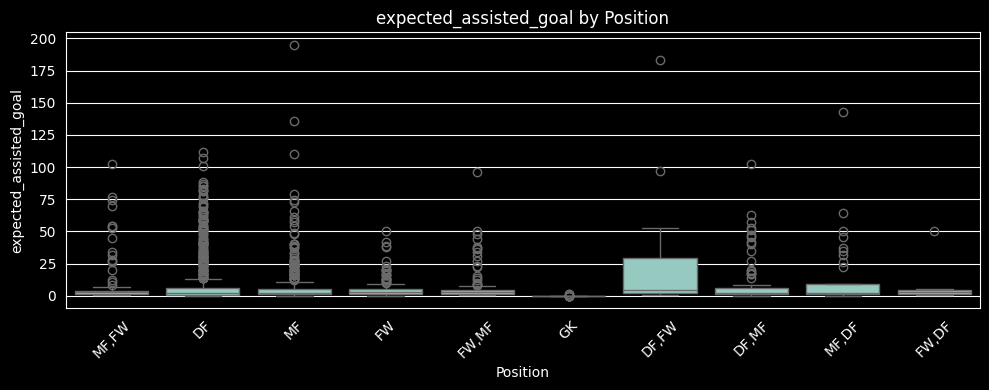

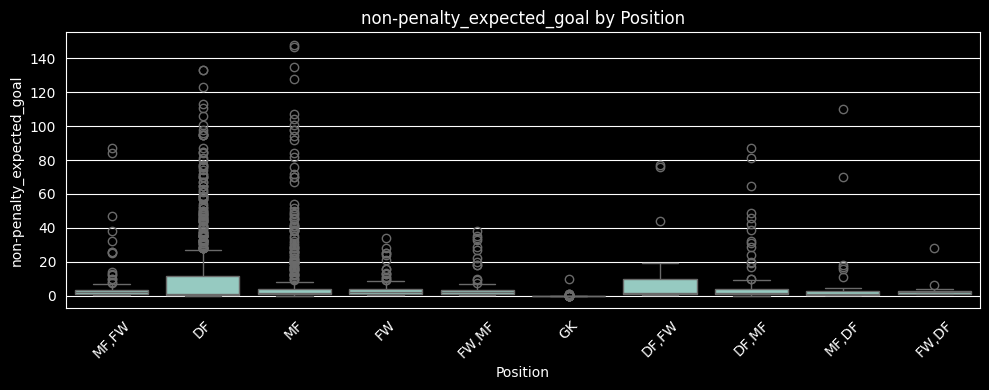

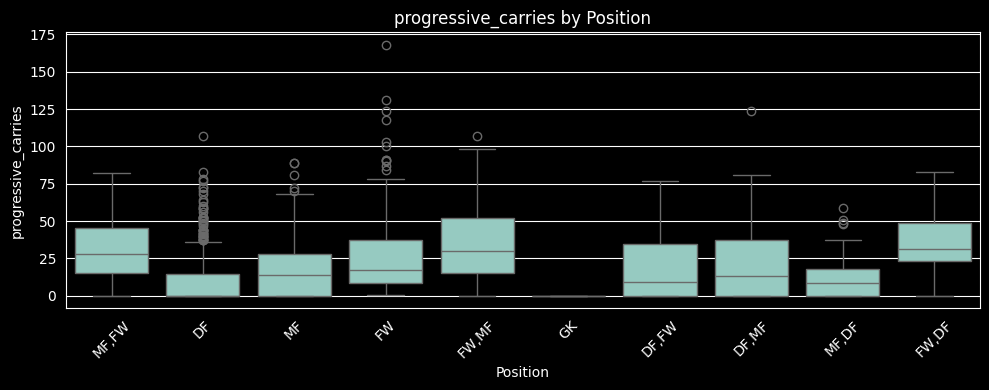

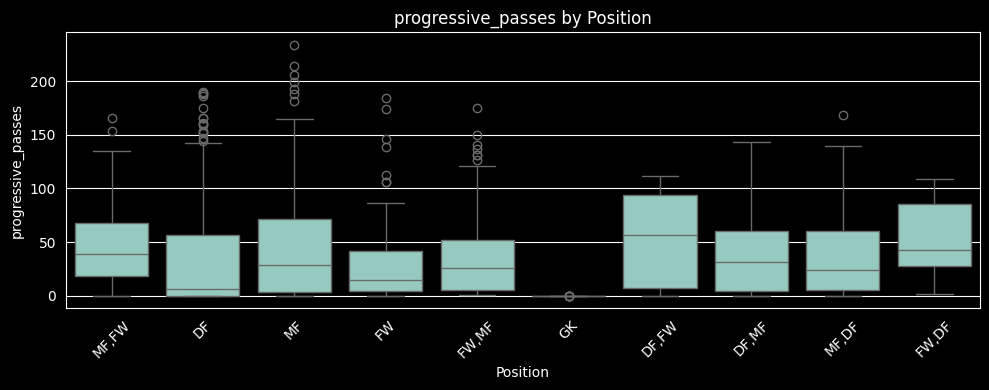

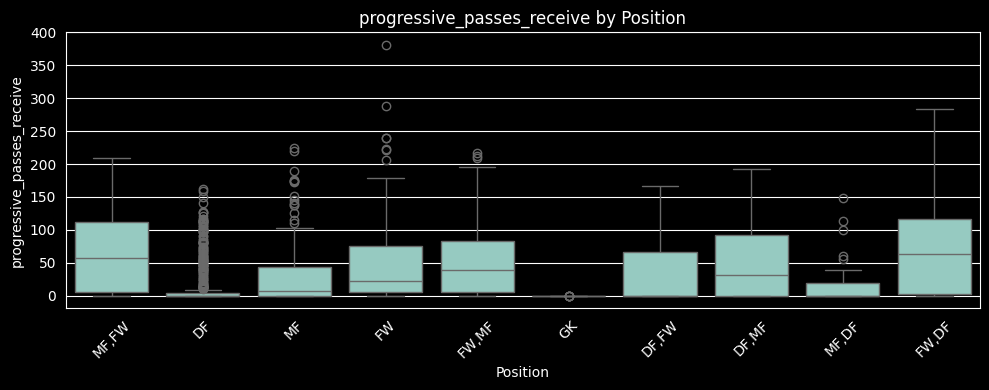

In [21]:
for col in numeric_cols:
    if col not in ['age_years','min']:
        plt.figure(figsize=(10,4))
        sns.boxplot(x="position",y=col,data=df)
        plt.title(f"{col} by Position")
        plt.xticks(rotation=45)
        plt.xlabel("Position")
        plt.tight_layout()
        plt.show()